In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="whitegrid")

Dimensions du dataset : (3089, 20)

Répartition des victoires de X :
x_wins
0    0.912593
1    0.087407
Name: proportion, dtype: float64


C:\Users\Fex\AppData\Local\Temp\ipykernel_9704\1954708668.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="x_wins", data=df, palette="viridis")
C:\Users\Fex\AppData\Local\Temp\ipykernel_9704\1954708668.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="is_draw", data=df, palette="magma")


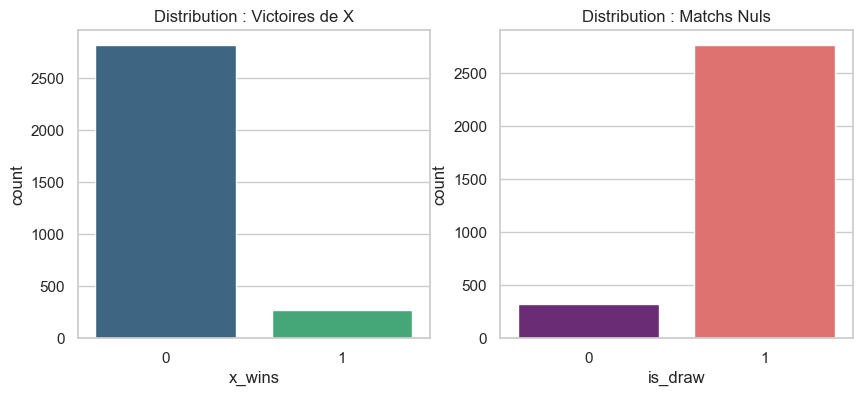

In [2]:
# Chargement du dataset généré à l'étape précédente
df = pd.read_csv("../../ressources/dataset_morpion.csv")

print(f"Dimensions du dataset : {df.shape}")
print("\nRépartition des victoires de X :")
print(df["x_wins"].value_counts(normalize=True))

# Visualisation de la distribution des cibles
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="x_wins", data=df, palette="viridis")
plt.title("Distribution : Victoires de X")

plt.subplot(1, 2, 2)
sns.countplot(x="is_draw", data=df, palette="magma")
plt.title("Distribution : Matchs Nuls")
plt.show()

In [3]:
# Séparation des features et des targets
X = df.drop(columns=["x_wins", "is_draw"])
y_wins = df["x_wins"]
y_draw = df["is_draw"]

# Découpage 80% entraînement / 20% test
X_train, X_test, y_train_wins, y_test_wins = train_test_split(
    X, y_wins, test_size=0.2, random_state=42
)
_, _, y_train_draw, y_test_draw = train_test_split(
    X, y_draw, test_size=0.2, random_state=42
)

In [4]:
# Configuration du modèle pour la victoire
model_wins = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

print("Entraînement du modèle de victoire...")
model_wins.fit(X_train, y_train_wins)

# Configuration du modèle pour le nul
model_draw = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
)

print("Entraînement du modèle de match nul...")
model_draw.fit(X_train, y_train_draw)

Entraînement du modèle de victoire...
Entraînement du modèle de match nul...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

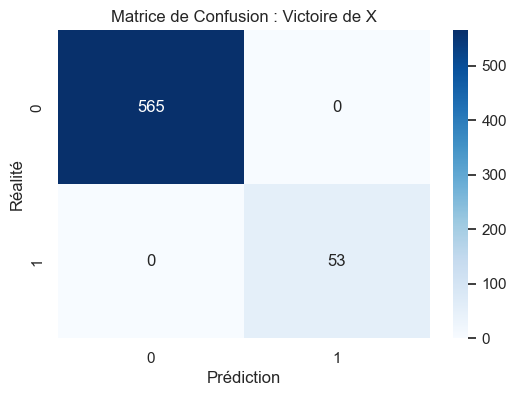


RAPPORT DE CLASSIFICATION (Victoires) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      1.00      1.00        53

    accuracy                           1.00       618
   macro avg       1.00      1.00      1.00       618
weighted avg       1.00      1.00      1.00       618



In [5]:
# Prédictions
y_pred_wins = model_wins.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test_wins, y_pred_wins)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion : Victoire de X')
plt.show()

print("\nRAPPORT DE CLASSIFICATION (Victoires) :")
print(classification_report(y_test_wins, y_pred_wins))

<Figure size 1000x600 with 0 Axes>

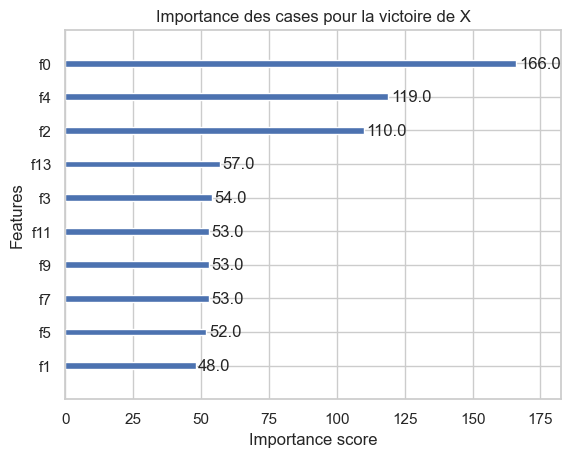

In [6]:
plt.figure(figsize=(10, 6))
plot_importance(model_wins, max_num_features=10, importance_type='weight')
plt.title("Importance des cases pour la victoire de X")
plt.show()

In [ ]:
# Export des modèles pour l'application finale
joblib.dump(model_wins, '../../ressources/model_xgboost_wins.pkl')
joblib.dump(model_draw, '../../ressources/model_xgboost_draw.pkl')

print("Modèles sauvegardés avec succès dans le dossier 'ressources/' !")

Modèles sauvegardés avec succès dans le dossier 'ressources/' !
